>[Нормальний розподіл](#scrollTo=jlG03TFH0Pfl)

>>[Лінійний дискримінантний аналіз (LDA)](#scrollTo=GFwy07BIHT_c)

>>[Застосування теореми Баєса в LDA](#scrollTo=7f_QgHhVITF3)

>>[Використання бібліотеки Sklearn](#scrollTo=aHWz3lvZJORt)

>[Квадратичний дискримінантний аналіз (QDA)](#scrollTo=8IBYcd36JdgL)

>>[Коваріаційна матриця](#scrollTo=l4VwS6EgNRI0)

>>[Коваріаційна матриця](#scrollTo=l4VwS6EgNRI0)

>>[Класифікатор на основі QDA](#scrollTo=9NmyXUVLPWD6)

>>[Використання бібліотеки Sklearn](#scrollTo=4NkRihT-Qast)

>[Додаткові матеріали](#scrollTo=PcS4T72N-hR4)



#Нормальний розподіл



Визначити імовірність того, що випадкова величина приймає значення менші заданого

In [1]:
from scipy.stats import norm

# Параметри розподілу
mu = 0  # середнє значення
sigma = 1  # стандартне відхилення

# Задана точка, для якої ми хочемо обчислити ймовірність P(X < x)
x = 2

# Обчислення функції розподілу
probability = norm.cdf(x, mu, sigma)

print(f'P(X < {x}) = {probability:.4f}')

P(X < 2) = 0.9772


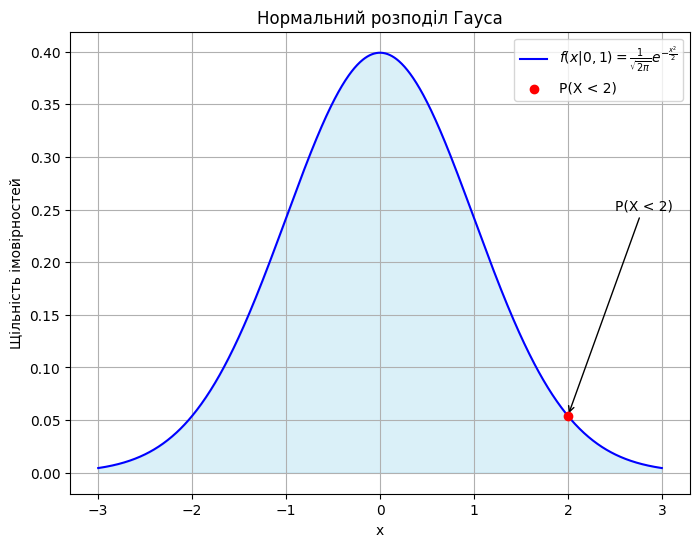

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

# Параметри розподілу
mu = 0
sigma = 1

# Створення значень x для графіка
x_values = np.linspace(-3, 3, 1000)

# Обчислення значень функції щільності ймовірностей (PDF)
pdf_values = norm.pdf(x_values, mu, sigma)

# Побудова графіка
plt.figure(figsize=(8, 6))
plt.plot(x_values, pdf_values, label=r'$f(x|0, 1) = \frac{1}{\sqrt{2\pi}} e^{-\frac{x^2}{2}}$', color='blue')
plt.fill_between(x_values, pdf_values, color='skyblue', alpha=0.3)

# Позначення точки x = 2
plt.scatter([2], [norm.pdf(2, mu, sigma)], color='red', label='P(X < 2)', zorder=5)
plt.annotate('P(X < 2)', xy=(2, norm.pdf(2, mu, sigma)), xytext=(2.5, 0.25),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Налаштування графіка
plt.title('Нормальний розподіл Гауса')
plt.xlabel('x')
plt.ylabel('Щільність імовірностей')
plt.legend()
plt.grid(True)

# Показати графік
plt.show()


## Лінійний дискримінантний аналіз (LDA)












In [3]:
import pandas as pd 

data = {'Height': [140, 145, 135, 169, 165, 142, 168, 141, 159, 160, 172],
        'Gender': ['F', 'F', 'F', 'M', 'F', 'M', 'M', 'F', 'F', 'M', 'M']}

df = pd.DataFrame(data)
print(df)


    Height Gender
0      140      F
1      145      F
2      135      F
3      169      M
4      165      F
5      142      M
6      168      M
7      141      F
8      159      F
9      160      M
10     172      M


In [4]:
df[df['Gender']=="F"].Height

0    140
1    145
2    135
4    165
7    141
8    159
Name: Height, dtype: int64

In [5]:
df[df['Gender']=="M"].Height

3     169
5     142
6     168
9     160
10    172
Name: Height, dtype: int64

### Check if dataset is Normal

In [6]:
from scipy.stats import shapiro

stat, p = shapiro(df[df['Gender']=="F"].Height)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
 print('Sample looks Gaussian (fail to reject H0)')
else:
 print('Sample does not look Gaussian (reject H0)')

Statistics=0.892, p=0.328
Sample looks Gaussian (fail to reject H0)


In [7]:
stat, p = shapiro(df[df['Gender']=="M"].Height)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
 print('Sample looks Gaussian (fail to reject H0)')
else:
 print('Sample does not look Gaussian (reject H0)')

Statistics=0.830, p=0.140
Sample looks Gaussian (fail to reject H0)


## Create intervals to see if satset is Normal 

In [8]:
def create_interval_dataframe(dataframe, step):
    """
    Перетворює датафрейм з ростом і статтю в інтервальний датафрейм.

    Параметри:
    - dataframe: pd.DataFrame, вихідний датафрейм зі стовпцями 'Зріст' і 'Стать'.
    - step: int, крок для побудови інтервалів.

    Повертає:
    - pd.DataFrame, інтервальний датафрейм зі стовпцями 'Інтервал', 'Чоловіки', 'Жінки'.
    """
    # Розрахунок мінімального та максимального зросту
    min_height = dataframe["Height"].min()
    max_height = dataframe["Height"].max()

    # Створення категорій для інтервалів
    categories = pd.cut(
        dataframe["Height"],
        bins=np.arange(min_height, max_height + step, step),
        right=False,
    )

    # Додавання нового стовпця 'Інтервал'
    dataframe["Interval"] = categories

    # Сортування індексів
    dataframe = dataframe.sort_values(by="Interval")

    # Групування за інтервалами та статтю, підрахунок частот
    grouped_df = (
        dataframe.groupby(["Interval", "Gender"]).size().unstack().reset_index()
    )

    return grouped_df


# Приклад використання:
# Визначення кроку
step = 3

result_df = create_interval_dataframe(df, step)

print(result_df)

Gender    Interval    F    M
0       [135, 138)  1.0  NaN
1       [138, 141)  1.0  NaN
2       [141, 144)  1.0  1.0
3       [144, 147)  1.0  NaN
4       [159, 162)  1.0  1.0
5       [165, 168)  1.0  NaN
6       [168, 171)  NaN  2.0
7       [171, 174)  NaN  1.0


In [9]:
df_f = df.loc[df['Gender'] == 'F']
df_f

,Height,Gender,Interval
0,140,F,"[138, 141)"
1,145,F,"[144, 147)"
2,135,F,"[135, 138)"
4,165,F,"[165, 168)"
7,141,F,"[141, 144)"
8,159,F,"[159, 162)"


In [10]:
df_m = df.loc[df['Gender'] == 'M']
df_m

,Height,Gender,Interval
3,169,M,"[168, 171)"
5,142,M,"[141, 144)"
6,168,M,"[168, 171)"
9,160,M,"[159, 162)"
10,172,M,"[171, 174)"


In [11]:
from scipy.stats import shapiro

shapiro(df_m.Height)

ShapiroResult(statistic=np.float64(0.8303580179339543), pvalue=np.float64(0.13998282851824687))

In [12]:
shapiro(df_f.Height)

ShapiroResult(statistic=np.float64(0.8917580998470673), pvalue=np.float64(0.3275021928417447))

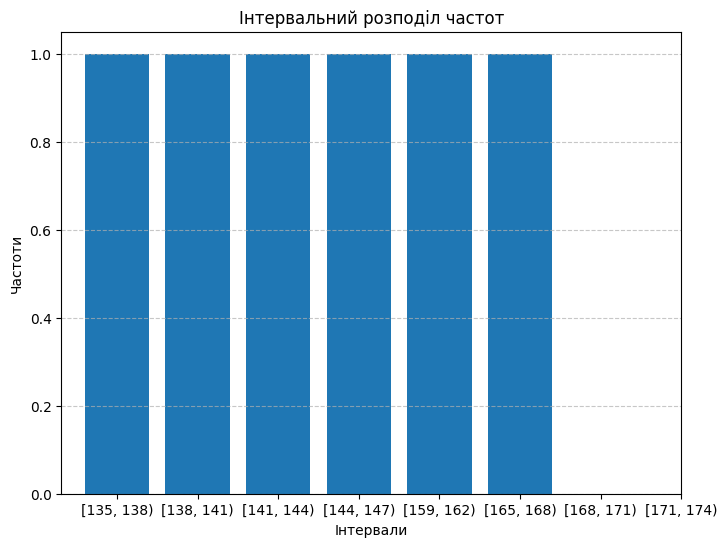

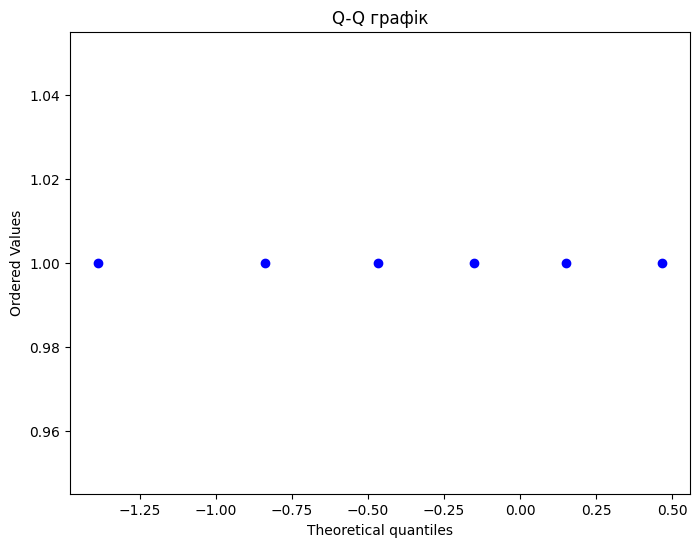

Shapiro-Wilk test statistic: nan, p-value: nan
Розподіл не є нормальним (відхиляється від нормального)


In [13]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt


data_f = result_df[['Interval', 'F']]

df_f = pd.DataFrame(data_f)


# Побудова графіка інтервального розподілу частот
plt.figure(figsize=(8, 6))
plt.bar(range(len(df_f)), df_f['F'], tick_label=df_f['Interval'].astype(str))
plt.title('Інтервальний розподіл частот')
plt.xlabel('Інтервали')
plt.ylabel('Частоти')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Побудова Q-Q графіка
plt.figure(figsize=(8, 6))
stats.probplot(df_f['F'], dist="norm", plot=plt)
plt.title('Q-Q графік')
plt.show()

# Перевірка нормальності тестом Шапіро-Уілка
stat, p_value = stats.shapiro(df_f['F'])
print(f'Shapiro-Wilk test statistic: {stat}, p-value: {p_value}')

# Визначення рівня значущості
alpha = 0.05

# Перевірка гіпотези про нормальність
if p_value > alpha:
    print("Розподіл є нормальним (не відхиляється від нормального)")
else:
    print("Розподіл не є нормальним (відхиляється від нормального)")


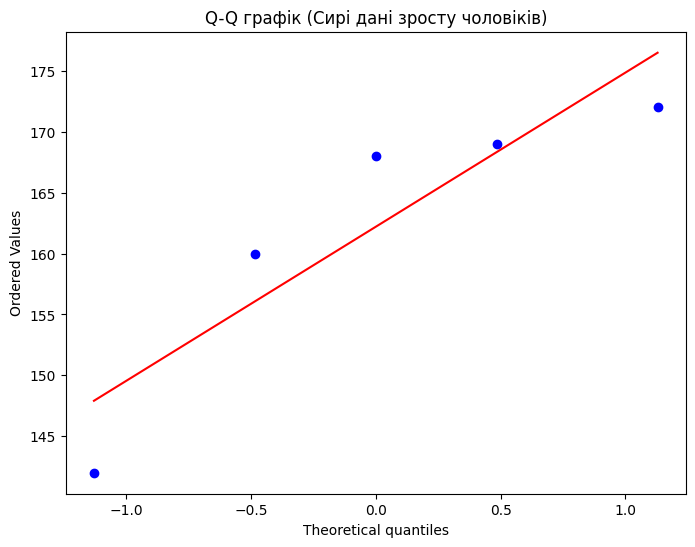

Shapiro-Wilk test statistic: 0.8304, p-value: 0.1400
Розподіл зросту є нормальним


In [14]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Беремо "сирі" дані зросту тільки для чоловіків з оригінального df
# (Припускаємо, що оригінальний df у тебе ще в пам'яті)
raw_male_heights = df[df['Gender'] == 'M']['Height']

# 2. Побудова правильного Q-Q графіка
plt.figure(figsize=(8, 6))
stats.probplot(raw_male_heights, dist="norm", plot=plt)
plt.title('Q-Q графік (Сирі дані зросту чоловіків)')
plt.show()

# 3. Правильна перевірка тестом Шапіро-Уілка
stat, p_value = stats.shapiro(raw_male_heights)
print(f'Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4f}')

# Висновок
if p_value > 0.05:
    print("Розподіл зросту є нормальним")
else:
    print("Розподіл зросту НЕ є нормальним")

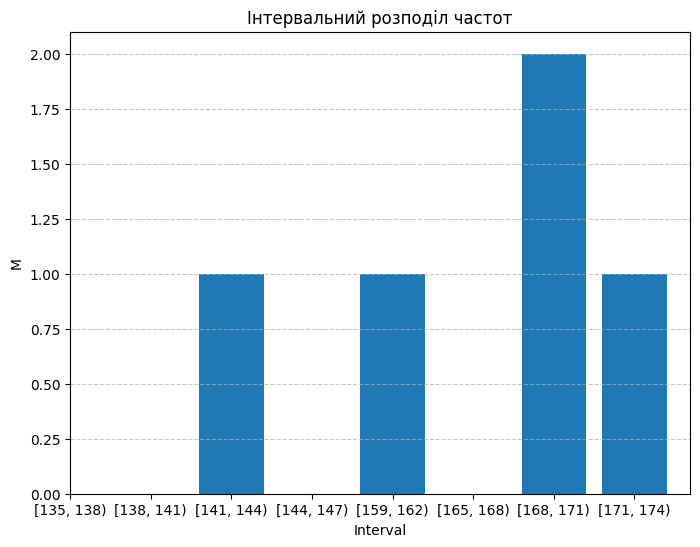

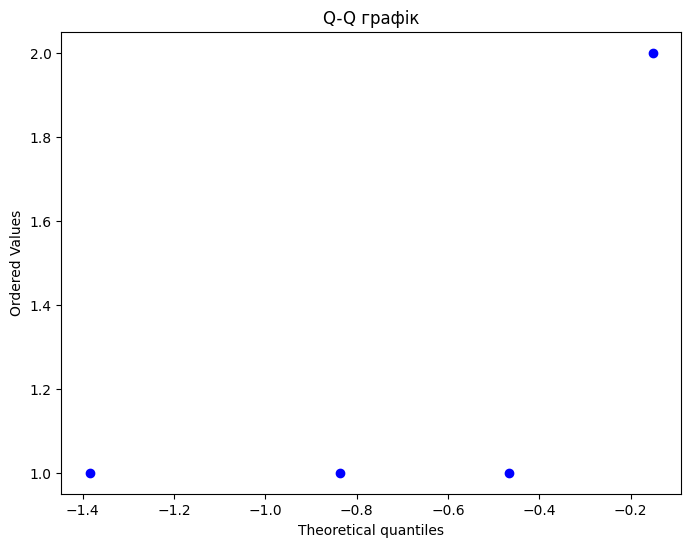

Shapiro-Wilk test statistic: nan, p-value: nan
Розподіл не є нормальним (відхиляється від нормального)


In [15]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

df_m = result_df[['Interval', 'M']]


# Побудова графіка інтервального розподілу частот
plt.figure(figsize=(8, 6))
plt.bar(range(len(df_m)), df_m['M'], tick_label=df_m['Interval'].astype(str))
plt.title('Інтервальний розподіл частот')
plt.xlabel('Interval')
plt.ylabel('M')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Побудова Q-Q графіка
plt.figure(figsize=(8, 6))
stats.probplot(df_m['M'], dist="norm", plot=plt)
plt.title('Q-Q графік')
plt.show()

# Перевірка нормальності тестом Шапіро-Уілка
stat, p_value = stats.shapiro(df_m['M'])
print(f'Shapiro-Wilk test statistic: {stat}, p-value: {p_value}')

# Визначення рівня значущості
alpha = 0.05

# Перевірка гіпотези про нормальність
if p_value > alpha:
    print("Розподіл є нормальним (не відхиляється від нормального)")
else:
    print("Розподіл не є нормальним (відхиляється від нормального)")


Тепер давайте обчислимо середнє значення та дисперсію для двох класів.

Для класу Female:

In [16]:
df[df['Gender']=='F']['Height'].std()

np.float64(11.827933040053955)

Для класу Male:

In [17]:
df[df['Gender']=='M']['Height'].std()

np.float64(12.132600710482482)

Дисперсія змінної, що розглядається, майже однакова в обох класах, отже, виконується друге припущення LDA.

##Застосування теореми Баєса в LDA

LDA значною мірою покладається на теорему Баєса, наведемо її у вигляді:

$\displaystyle P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B|A)\cdot P(A) + P(B|\neg A)\cdot P(\neg A)}, $

де

- $ P(A) $ — апріорна ймовірність події $A$.
- $ P(\neg A)$ — апріорна ймовірність не настання події $A$.
- $ P(B|A) $ — умовна ймовірність події $B$ за умови виконання $A$.
- $ P(B|\neg A) $ — умовна ймовірність події $B$ за умови не виконання $A$.

Для наданої нам таблиці даних потрібно обчислити ймовірність того, що значення нової висоти потрапляє у два класи статі. Це означає, що нам доведеться розрахувати:

$P (стать = чоловік | зріст = 152)$ і $P (стать = жінка | зріст = 152)$, а потім порівняти, яке значення ймовірності вище.

Отже, маємо

$\displaystyle P(\text{gender=male}|\text{height=152}) = \frac{P(\text{height=152}|\text{gender=male}) \cdot P(\text{gender=male})}{P(\text{height=152}|\text{gender=male}) \cdot P(\text{gender=male})+P(\text{height=152}|\text{gender=female}) \cdot P(\text{gender=female})} $

та

$\displaystyle P(\text{gender=female}|\text{height=152}) = \frac{P(\text{height=152}|\text{gender=female}) \cdot P(\text{gender=female})}{P(\text{height=152}|\text{gender=female}) \cdot P(\text{gender=female})+P(\text{height=152}|\text{gender=male}) \cdot P(\text{gender=male})} $


$P(gender=male)$ можна легко обчислити як кількість елементів у чоловічому класі в наборі навчальних даних, поділену на загальну кількість елементів:

In [63]:
P_m = len(df[df['Gender']=='M'])/len(df)
P_m

0.45454545454545453

Так само отримаємо $P(gender=female)$ як кількість елементів у жіночому класі в наборі навчальних даних, поділену на загальну кількість елементів:


In [64]:
P_f = len(df[df['Gender']=='F'])/len(df)
P_f

0.5454545454545454

Після цього необхідно обчислити умовні ймовірності, однак, це буде зроблено за допомогою нормального розподілу. Саме тут нам знадобиться перше припущення LDA.

Отже, для випадкової змінної відомо, що вона підкоряється нормальному закону розподілу:

$ f(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}} $

Раніше ми обчислили середнє та дисперсію для кожного класу. Підставимо їх та отримаємо значення розподілу в точці, що нас цікавить.


In [ ]:
import math
std_m = df[df['Gender']=='M']['Height'].std()
sigma_m = std_m**2
mu_m = df[df['Gender']=='M']['Height'].mean()


std_f = df[df['Gender']=='F']['Height'].std()
sigma_f = std_f**2
mu_f = df[df['Gender']=='F']['Height'].mean()


def norm_distr(x, mu, sigma):
    # Здесь sigma — это стандартное отклонение. В квадрат оно возводится только внутри экспоненты.
    return (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mu) / sigma) ** 2)


P_h_m = norm_distr(152, mu_m, std_m)
P_h_m

np.float64(0.00270370687048309)

Це і є значення умовної ймовірності $P(\text{height=152}|\text{gender=male}).$

Female Class

In [69]:
P_h_f = norm_distr(152, mu_f, std_f)
P_h_f

np.float64(0.0313740049209477)

Це і є значення умовної ймовірності $P(\text{height=152}|\text{gender=female}).$

Далі підставляємо отримані значення у формулу.

$\displaystyle P(\text{gender=male}|\text{height=152}) = \frac{P(\text{height=152}|\text{gender=male}) \cdot P(\text{gender=male})}{P(\text{height=152}|\text{gender=male}) \cdot P(\text{gender=male})+P(\text{height=152}|\text{gender=female}) \cdot P(\text{gender=female})}$

In [70]:
P_m_h = P_h_m*P_m/(P_h_m*P_m+P_h_f*P_f)
P_m_h

np.float64(0.3801816386527418)

та

$\displaystyle P(\text{gender=female}|\text{height=152}) = \frac{P(\text{height=152}|\text{gender=female}) \cdot P(\text{gender=female})}{P(\text{height=152}|\text{gender=female}) \cdot P(\text{gender=female})+P(\text{height=152}|\text{gender=male}) \cdot P(\text{gender=male})} $

In [71]:
P_f_h = P_h_f*P_f/(P_h_f*P_f+P_h_m*P_m)
P_f_h

np.float64(0.6198183613472582)

Тепер, оскільки очевидно, що $P(стать = чоловік| зріст = 152)$ менший, ніж $P(стать = жінка |зріст = 152)$, ми можемо класифікувати зріст $152$ см до жіночого класу.

In [72]:
import math
import pandas as pd

# Предполагаем, что твой df с сырыми данными (Height, Gender) загружен
# Считаем правильные параметры: СРЕДНЕЕ и СТАНДАРТНОЕ ОТКЛОНЕНИЕ (std)
# mu_m = df[df['Gender'] == 'M']['Height'].mean()
# print(f"Mu:{mu_m}")
# std_m = df[df['Gender'] == 'M']['Height'].std()  # Строго std!

# mu_f = df[df['Gender'] == 'F']['Height'].mean()
# std_f = df[df['Gender'] == 'F']['Height'].std()  # Строго std!

# 1. Исправленная функция плотности (Likelihood)
def norm_distr_2(x, mu, sigma):
    # Здесь sigma — это стандартное отклонение. В квадрат оно возводится только внутри экспоненты.
    return (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mu) / sigma) ** 2)

x_new = 152

# 2. Считаем P(h|m) и P(h|f)
P_h_m = norm_distr_2(x_new, mu_m, std_m)
P_h_f = norm_distr_2(x_new, mu_f, std_f)

# 3. Считаем Priors (доли в датасете)
P_m = len(df[df['Gender'] == 'M']) / len(df)
P_f = len(df[df['Gender'] == 'F']) / len(df)

# 4. ТА САМАЯ ФОРМУЛА БАЙЕСА ИЗ ТВОЕГО КУРСА
P_m_h = (P_h_m * P_m) / (P_h_m * P_m + P_h_f * P_f)
P_f_h = (P_h_f * P_f) / (P_h_m * P_m + P_h_f * P_f)

print(f"Вероятность, что это Мужчина (P_m_h): {P_m_h * 100:.2f}%")
print(f"Вероятность, что это Женщина (P_f_h): {P_f_h * 100:.2f}%")

Вероятность, что это Мужчина (P_m_h): 38.02%
Вероятность, что это Женщина (P_f_h): 61.98%


## Використання бібліотеки Sklearn

In [73]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

height = np.array(df['Height'])
gender = np.array(df['Gender'])

lda = LinearDiscriminantAnalysis()
lda.fit(height.reshape(-1,1), gender)
x = np.array([152])

lda.predict_proba(x.reshape(-1,1))

array([[0.61656602, 0.38343398]])

In [74]:
gender

array(['F', 'F', 'F', 'M', 'F', 'M', 'M', 'F', 'F', 'M', 'M'],
      dtype=object)

In [75]:
lda.predict(x.reshape(-1,1))

array(['F'], dtype='<U1')

#Квадратичний дискримінантний аналіз (QDA)


##Коваріаційна матриця

##Коваріаційна матриця

**Коваріаційна матриця** — це матриця, яка містить коваріації між парами змінних у векторі випадкових величин. Вона дозволяє визначити ступінь лінійної залежності між різними змінними та міру їхнього взаємозв'язку.

Для двох змінних $X$ та $Y$ коваріаційна матриця має вигляд:

$ \text{Cov}(X, Y) = \begin{bmatrix} \text{Var}(X) & \text{Cov}(X, Y) \\ \text{Cov}(Y, X) & \text{Var}(Y) \end{bmatrix} $

де:
- $\text{Var}(X)$ — дисперсія $X$,
- $\text{Var}(Y)$ — дисперсія $Y$,
- $\text{Cov}(X, Y)$ — коваріація між $X$ та $Y$,
- $\text{Cov}(Y, X)$ — коваріація між $Y$ та $X$.


$\displaystyle
\text{Var}(X) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu_x)^2.
$


$\displaystyle
\text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu_x)(y_i - \mu_y).
$

У формулах вище $\mu_x$ і $\mu_y$ — середні значення змінних $X$ та $Y$ відповідно.

Слід звернути увагу на коефіцієнт $\displaystyle \frac{1}{n-1}$. Коли ми працюємо з реальними даними, ми часто не знаємо середнього значення сукупності. Ми знаємо лише вибіркове середнє значення. Тому ми повинні використовувати формулу з $n-1$. Коли ми маємо всю генеральну сукупність даних, можна використовувати $n$.


**Приклад.**
Нехай маємо три змінні: $X$, $Y$ і $Z$ — та набір даних:

$ X = [x_1, x_2, ..., x_n]=[1, 2, 3, 4, 5] $

$ Y = [y_1, y_2, ..., y_n] = [2, 4, 6, 8, 11] $

$ Z = [z_1, z_2, ..., z_n] = [-1, -2, -3, -4, -5] $

Для розрахунку коваріаційної матриці спочатку потрібно розрахувати дисперсії та коваріації.

Після розрахунку всіх необхідних значень коваріаційна матриця матиме вигляд:

$ \text{Covariance Matrix} = \begin{bmatrix} \text{Var}(X) & \text{Cov}(X, Y) & \text{Cov}(X, Z) \\ \text{Cov}(Y, X) & \text{Var}(Y) & \text{Cov}(Y, Z) \\ \text{Cov}(Z, X) & \text{Cov}(Z, Y) & \text{Var}(Z) \end{bmatrix} $

Використаємо Numpy для розрахунків.





In [28]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 11]
z = [-1, -2, -3, -4, -5]


In [29]:
var_x = np.var(x)*len(x)/(len(x)-1)
var_x

np.float64(2.5)

In [30]:
var_y = np.var(y)*len(y)/(len(y)-1)
var_y

np.float64(12.2)

In [31]:
var_z = np.var(z)*len(z)/(len(z)-1)
var_z

np.float64(2.5)

In [32]:
X = np.stack((x, y, z), axis=0)
print(X)
print('Матриця коваріації\n',np.cov(X))

[[ 1  2  3  4  5]
 [ 2  4  6  8 11]
 [-1 -2 -3 -4 -5]]
Матриця коваріації
 [[ 2.5  5.5 -2.5]
 [ 5.5 12.2 -5.5]
 [-2.5 -5.5  2.5]]


##Класифікатор на основі QDA

Розглянемо попередню задачу про прогнозування статі людини за зростом, що ми розглядали в методі LDA. Але пам'ятаємо, що оскільки метод QDA не вимагає однакових дисперсій ознак за класами, ця вимога не є обов'язковою.





In [33]:
data = {'Height': [140, 145, 135, 169, 165, 142, 168, 141, 159, 160, 172],
        'Gender': ['F', 'F', 'F', 'M', 'F', 'M', 'M', 'F', 'F', 'M', 'M']}

df = pd.DataFrame(data)
print(df)


    Height Gender
0      140      F
1      145      F
2      135      F
3      169      M
4      165      F
5      142      M
6      168      M
7      141      F
8      159      F
9      160      M
10     172      M


Отже, оскільки в нас два класи: male та female — дискримінантна формула для кожного класу набуває вигляду:

$ g_m(x) = -\frac{1}{2} (x_m - \mu_m)^T \Sigma_i^{-1} (x_m - \mu_m)  - \frac{1}{2} \ln|\Sigma_m| + \ln P(C_m), $
$ g_f(x) = -\frac{1}{2} (x_f - \mu_f)^T \Sigma_i^{-1} (x_f - \mu_f)  - \frac{1}{2} \ln|\Sigma_f| + \ln P(C_f).$


Знайдемо значення ознаки в кожному класі.

In [34]:
from numpy.linalg import inv
x_m = np.array(df[df['Gender']=='M']['Height'])
x_m

array([169, 142, 168, 160, 172])

In [35]:
x_f = np.array(df[df['Gender']=='F']['Height'])
x_f

array([140, 145, 135, 165, 141, 159])

In [36]:
np.cov(x_m)

array(147.2)

Знайдемо значення коваріації, яка в цьому випадку дорівнює дисперсії даних за класами.

In [37]:
x_m_cov = np.var(x_m)*len(x_m)/(len(x_m)-1)
x_m_cov

np.float64(147.20000000000002)

In [38]:
x_f_cov = np.var(x_f)*len(x_f)/(len(x_f)-1)
x_f_cov

np.float64(139.9)

Знайдемо обернені значення коваріації для кожного класу

In [39]:
inv_cov_m = inv(np.array([[x_m_cov]]))
inv_cov_m

array([[0.00679348]])

In [40]:
inv_cov_f = inv(np.array([[x_f_cov]]))
inv_cov_f

array([[0.00714796]])

Та апріорні ймовірності кожного класу.

In [41]:
P_m = len(df[df['Gender']=='M'])/len(df)
P_m

0.45454545454545453

In [42]:
P_f = len(df[df['Gender']=='F'])/len(df)
P_f

0.5454545454545454

Визначимо дискримінантну функцію для випадку однієї ознаки в наборі даних.

In [43]:
def g(x, X_mean, X_cov, X_inv_cov, X_prob):
    g_i = -1/2*(x - X_mean)*(x - X_mean)*X_inv_cov - 1/2*np.log(X_cov)+np.log(X_prob)
    return g_i

Значення дискримінантної функції для класу чоловіків.

In [44]:
g_m = g(170, np.mean(x_m), x_m_cov, inv_cov_m, P_m)
g_m

array([[-3.49101107]])

Значення дискримінантної функції для класу жінок.

In [45]:
g_f = g(170, np.mean(x_f), x_f_cov, inv_cov_f, P_f)
g_f

array([[-4.88592784]])

Сформуємо вектор значень дискримінантної функції.

In [46]:
values = np.array(list([g_m[0], g_f[0]])).transpose()
values

array([[-3.49101107, -4.88592784]])

Обчислимо вектор імовірності приналежності до двох класів.

In [47]:
likelihood = np.exp(values - values.max(axis=1)[:, np.newaxis])
res = likelihood / likelihood.sum(axis=1)[:, np.newaxis]
res

array([[0.80137602, 0.19862398]])

##Використання бібліотеки Sklearn

In [48]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

height = np.array(df['Height'])
gender = np.array(df['Gender'])

qda = QuadraticDiscriminantAnalysis()
qda.fit(height.reshape(-1,1), gender)
x = np.array([170])

print('Значення дискримінантної функції\n', qda._decision_function(x.reshape(-1,1)))

print('Значення ймовірностей класів\n', qda.predict_proba(x.reshape(-1,1)))

Значення дискримінантної функції
 [[-4.88592784 -3.49101107]]
Значення ймовірностей класів
 [[0.19862398 0.80137602]]


In [49]:
qda.predict(x.reshape(-1,1))

array(['M'], dtype=object)

Можна побачити, що значення дискримінантної функції та значення ймовірностей класів збігаються в розрахунках за допомогою Numpy та Sklearn.

In [50]:
men_data = np.array([
    [180, 80], [175, 78], [185, 83],
    [178, 85], [182, 77], [176, 82]
])

In [51]:
women_data = np.array([
    [160, 60], [165, 58], [170, 63],
    [163, 52], [168, 65], [162, 57]
])

In [52]:
np.cov(men_data.T)

array([[14.26666667,  0.86666667],
       [ 0.86666667,  9.36666667]])

In [53]:
np.cov(women_data.T)

array([[14.26666667, 10.66666667],
       [10.66666667, 21.36666667]])

# Додаткові матеріали

1. По виведенню LDA/QDA: https://xavierbourretsicotte.github.io/LDA_QDA.html
https://maelfabien.github.io/machinelearning/LDA/#
2. Тести на нормальний розподіл: https://machinelearningmastery.com/a-gentle-introduction-to-normality-tests-in-python/
3. Про CDF функцію: https://machinelearningmastery.com/continuous-probability-distributions-for-machine-learning/
4. По розподілах: https://machinelearningmastery.com/statistical-data-distributions/
5. Класний ресурс по теорії ймовірності: https://online.stat.psu.edu/stat414/section/1
6. Linear Discriminant Analysis in Machine Learning:  https://www.geeksforgeeks.org/ml-linear-discriminant-analysis/